# Escalamiento y Normalización de Datos

En este JNB se revisará el tema de Escalamiento y Normalización de Datos.

In [4]:
# módulos que usaremos
import pandas as pd
import numpy as np

# para la Transformación Box-Cox
from scipy import stats

# para el escalado min-max
from mlxtend.preprocessing import minmax_scaling

# módulos de graficación
import seaborn as sns
import matplotlib.pyplot as plt

# establecer semilla para reproducibilidad
np.random.seed(0)

Escalar vs Normalizar ¿Cual es la diferencia?
en el escalado, estas cambiando el rango de los datos
en la normalizacion, estas cambiando la forma de la distribucion de los datos

*ESCALADO*
podrías estar observando los precios de algunos productos tanto en Yenes como en Dólares estadounidenses. Un dólar vale unos 100 yenes, pero si no escalas tus precios, métodos como SVM o KNN considerarán que una diferencia de precio de 1 yen es tan importante como una diferencia de 1 dólar. Claramente, esto no encaja con nuestra intuición del mundo. Con las divisas, puedes convertir entre ellas. Pero, ¿qué pasa si estás mirando algo como la altura y el peso? No está del todo claro cuántas libras deberían equivaler a una pulgada (o cuántos kilogramos a un metro).

Al escalar tus variables, puedes ayudar a comparar diferentes variables en igualdad de condiciones. Para ayudar a consolidar cómo se ve el escalado, veamos un ejemplo ficticio.

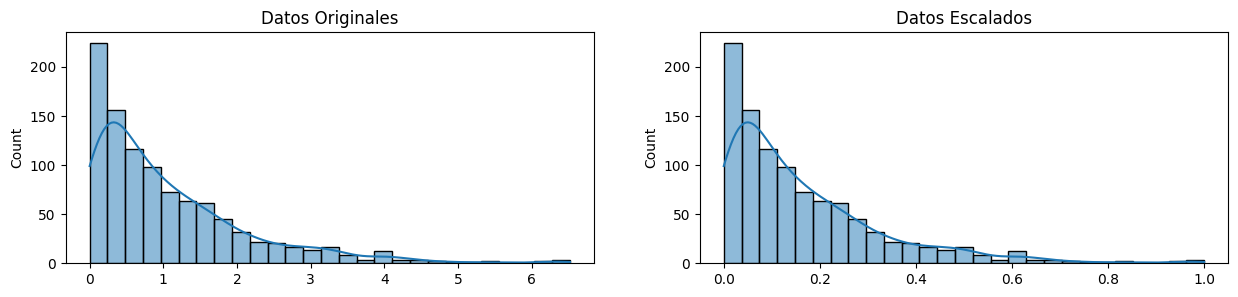

In [6]:
original_data = np.random.exponential(size=1000)
scaled_data = minmax_scaling(original_data, columns=[0])

#graficar ambos juntos para comparar
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title('Datos Originales')
sns.histplot(scaled_data.flatten(), ax=ax[1], kde=True, legend=False)
ax[1].set_title('Datos Escalados')
plt.show()

*NORMALIZACIÓN*
El escalado solo cambia el rango de tus datos. La normalización es una transformación más radical. El objetivo de la normalización es cambiar tus observaciones para que puedan describirse como una distribución normal.

Distribución normal: También conocida como la "curva de campana", es una distribución estadística específica donde una cantidad aproximadamente igual de observaciones cae por encima y por debajo de la media, la media y la mediana son iguales, y hay más observaciones cerca de la media. La distribución normal también se conoce como distribución Gaussiana.

En general, normalizarás tus datos si vas a utilizar una técnica de aprendizaje automático o estadística que asuma que tus datos tienen una distribución normal. Algunos ejemplos incluyen el Análisis Discriminante Lineal (LDA) y el Naive Bayes Gaussiano. (Consejo profesional: cualquier método con "Gaussiano" en el nombre probablemente asume normalidad).

El método que usamos para normalizar aquí se llama Transformación Box-Cox. Echemos un vistazo rápido a cómo se ve la normalización de algunos datos

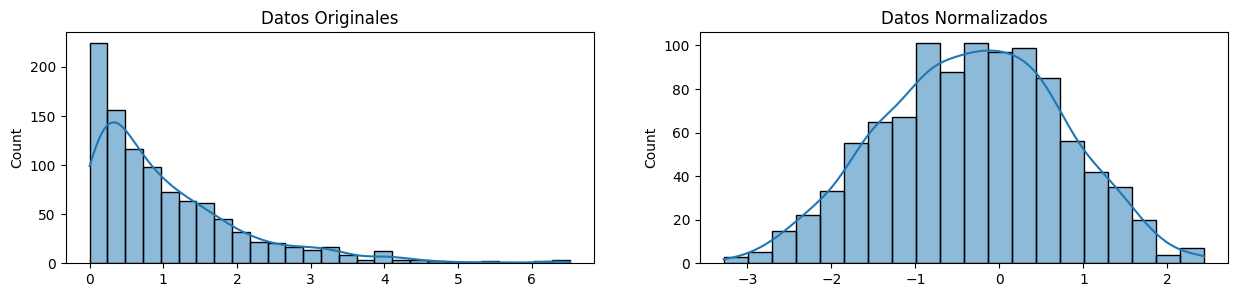

In [7]:
normalized_data = stats.boxcox(original_data)

fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Datos Originales")
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Datos Normalizados")
plt.show()